In [277]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from great_tables import GT, style, loc

In [174]:
df_grade4 = pd.read_stata(r"F:\python-files\econ-481\project-business-decisions-didida2007\data\final4.dta")
df_grade5 = pd.read_stata(r"F:\python-files\econ-481\project-business-decisions-didida2007\data\final5.dta")

In [ ]:
def predict_class_size(df):
    predicted_size = df['c_size'] / (np.floor((df['c_size'] - 1) / 40) + 1)
    df['p_size'] = predicted_size
    return df

In [249]:
df_grade4 = predict_class_size(df_grade4)
df_grade5 = predict_class_size(df_grade5)

In [250]:
def descriptive_table(df):

    row = df[["classize", "c_size", "tipuach", "verbsize", "mathsize", "avgverb", "avgmath"]]
    row_index = ["Class Size", "Enrollment", "Percentage Disadvantaged", "Reading Size", "Math Size", "Average Verbal", "Average Math"]
    
    grade = df["grade"][0]
    class_num = len(df)
    school_num = df["schlcode"].nunique()

    table = pd.DataFrame({
        "mean": row.mean(),
        "std": row.std(),
        "q10": row.quantile(0.1),
        "q25": row.quantile(0.25),
        "q50": row.quantile(0.5),
        "q75": row.quantile(0.75),
        "q90": row.quantile(0.9)
    })

    table.index = row_index
    table.index.name = "Variable"

    table = table.round(1).astype(object)
    table.iloc[:5, -5:] = table.iloc[:5, -5:].round(0).astype(int)

    table_gt = GT(table.reset_index()
    ).tab_spanner(
        label = "Quantiles",
        columns = ["q10", "q25", "q50", "q75", "q90"]
    ).tab_header(
        title = "Unweighted Descriptive Statistics",
        subtitle = f"{grade}th Grade ({class_num} classes, {school_num} schools)"
    ).cols_label(
        mean ="Mean",
        std = "S.D.",
        q10 = "0.10",
        q25 = "0.25",
        q50 = "0.50",
        q75 = "0.75",
        q90 = "0.90"
    ).cols_align(
        align = "left",
        columns = "Variable"
    ).cols_align(
        align = "center",
        columns = ["mean", "std", "q10", "q25", "q50", "q75", "q90"]
    )

    return table_gt

In [251]:
descriptive_table(df_grade5)

GT(_tbl_data=                   Variable  mean   std   q10   q25   q50   q75   q90
0                Class Size  30.0   6.6    21    26    31    35    38
1                Enrollment  77.9  39.1    31    50    72   100   128
2  Percentage Disadvantaged  14.1  13.5     2     4    10    19    35
3              Reading Size  27.3   6.6    19    23    28    32    36
4                 Math Size  27.7   6.7    19    23    28    33    36
5            Average Verbal  74.4   8.1  64.2  69.9  75.4  79.8  83.3
6              Average Math  67.3  10.0  54.9  61.1  67.8  74.1  79.4, _body=<great_tables._gt_data.Body object at 0x000001B629D44690>, _boxhead=Boxhead([ColInfo(var='Variable', type=<ColInfoTypeEnum.default: 1>, column_label='Variable', column_align='left', column_width=None), ColInfo(var='mean', type=<ColInfoTypeEnum.default: 1>, column_label='Mean', column_align='center', column_width=None), ColInfo(var='std', type=<ColInfoTypeEnum.default: 1>, column_label='S.D.', column_align='center', column_width=None), ColInfo(var='q10', type=<ColInfoTypeEnum.default: 1>, column_label='0.10', column_align='center', column_width=None), ColInfo(var='q25', type=<ColInfoTypeEnum.default: 1>, column_label='0.25', column_align='center', column_width=None), ColInfo(var='q50', type=<ColInfoTypeEnum.default: 1>, column_label='0.50', column_align='center', column_width=None), ColInfo(var='q75', type=<ColInfoTypeEnum.default: 1>, column_label='0.75', column_align='center', column_width=None), ColInfo(var='q90', type=<ColInfoTypeEnum.default: 1>, column_label='0.90', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000001B629D36E70>, _spanners=Spanners([SpannerInfo(spanner_id='Quantiles', spanner_level=0, spanner_label='Quantiles', spanner_units=None, spanner_pattern=None, vars=['q10', 'q25', 'q50', 'q75', 'q90'], built=None)]), _heading=Heading(title='Unweighted Descriptive Statistics', subtitle='5th Grade (2029 classes, 1004 schools)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000001B629D37B90>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000001B629D37BF0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000001B6247C4140>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px',

In [252]:
def discontinuity_table(df1, df2):

    query_str = (
    "(c_size >= 36 & c_size <= 45) | "
    "(c_size >= 76 & c_size <= 85) | "
    "(c_size >= 116 & c_size <= 125)"
    )

    df1_filtered, df2_filtered = [df.query(query_str) for df in [df1, df2]]

    col = ["classize", "c_size", "tipuach", "verbsize", "mathsize", "avgverb", "avgmath"]
    row1 = df1_filtered[col]
    row2 = df2_filtered[col]
    row_index = ["Class Size", "Enrollment", "Percentage Disadvantaged", "Reading Size", "Math Size", "Average Verbal", "Average Math"]

    [grade1, grade2] = [df1["grade"][0], df2["grade"][0]]
    [class1_num, class2_num] = [len(df1), len(df2)]
    [school1_num, school2_num] = [df1["schlcode"].nunique(), df2["schlcode"].nunique()]

    table = pd.DataFrame({
        "mean1": row1.mean(),
        "std1": row1.std(),
        "mean2": row2.mean(),
        "std2": row2.std()
    })

    table.index = row_index
    table.index.name = "Variable"

    table = table.round(1)

    table_gt = GT(table.reset_index()
    ).tab_spanner(
        label=f"{grade1}th Grade ({class1_num} classes, {school1_num} schools)",
        columns=["mean1", "std1"]
    ).tab_spanner(
        label=f"{grade2}th Grade ({class2_num} classes, {school2_num} schools)",
        columns=["mean2", "std2"]
    ).tab_header(
        title = "+/-5 Discontinuity Sample",
        subtitle = "Enrollment 36-45, 76-85, 116-124"
    ).cols_label(
        mean1 = "Mean",
        std1 = "S.D.",
        mean2 = "Mean",
        std2 = "S.D."
    ).cols_align(
        align="left",
        columns="Variable"
    ).cols_align(
        align="center",
        columns=["mean1", "std1", "mean2", "std2"]
    )

    return table_gt

In [253]:
discontinuity_table(df_grade5, df_grade4)

GT(_tbl_data=                   Variable  mean1  std1  mean2  std2
0                Class Size   30.9   7.4   31.2   7.3
1                Enrollment   76.4  29.5   78.4  30.0
2  Percentage Disadvantaged   13.6  13.2   12.9  12.4
3              Reading Size   28.2   7.3   28.3   7.7
4                 Math Size   28.6   7.4   28.7   7.7
5            Average Verbal   74.5   8.2   72.5   7.8
6              Average Math   67.1  10.2   68.7   9.1, _body=<great_tables._gt_data.Body object at 0x000001B629E00A00>, _boxhead=Boxhead([ColInfo(var='Variable', type=<ColInfoTypeEnum.default: 1>, column_label='Variable', column_align='left', column_width=None), ColInfo(var='mean1', type=<ColInfoTypeEnum.default: 1>, column_label='Mean', column_align='center', column_width=None), ColInfo(var='std1', type=<ColInfoTypeEnum.default: 1>, column_label='S.D.', column_align='center', column_width=None), ColInfo(var='mean2', type=<ColInfoTypeEnum.default: 1>, column_label='Mean', column_align='center', column_width=None), ColInfo(var='std2', type=<ColInfoTypeEnum.default: 1>, column_label='S.D.', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000001B629D421B0>, _spanners=Spanners([SpannerInfo(spanner_id='5th Grade (2029 classes, 1004 schools)', spanner_level=0, spanner_label='5th Grade (2029 classes, 1004 schools)', spanner_units=None, spanner_pattern=None, vars=['mean1', 'std1'], built=None), SpannerInfo(spanner_id='4th Grade (2059 classes, 1016 schools)', spanner_level=0, spanner_label='4th Grade (2059 classes, 1016 schools)', spanner_units=None, spanner_pattern=None, vars=['mean2', 'std2'], built=None)]), _heading=Heading(title='+/-5 Discontinuity Sample', subtitle='Enrollment 36-45, 76-85, 116-124', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000001B629E10A10>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000001B629E10A70>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000001B629E00A50>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=Opt

In [301]:
def plot_maimonides_sawtooth(df):

    grade = df["grade"][0]

    # 1. Create the theoretical Maimonides Rule line
    e = np.linspace(df['c_size'].min(), df['c_size'].max(), 1000)
    theoretical_rule = e / (np.floor((e - 1) / 40) + 1)

    # 2. Setup the figure
    plt.figure(figsize=(10, 6))

    # Plot Actual Class Size (Solid)
    actual_means = df.groupby('c_size')['classize'].mean()
    plt.plot(actual_means.index, actual_means.values, 
             color='black', linewidth=1, label='Actual class size')

    # Plot Maimonides Rule (Dashed)
    plt.plot(e, theoretical_rule, 
             color='blue', linestyle='--', linewidth=1.5, label='Maimonides Rule')

    # 3. Add the horizontal "Corner" lines
    for y in [20.5, 27, 30.3, 32, 33.5, 40]:
        plt.axhline(y=y, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)

    # 4. Formatting
    plt.xlabel('Enrollment count')
    plt.ylabel('Class size')
    plt.title(f'{grade}th Grade')
    plt.legend(frameon=True, loc='lower right')
    
    # Remove top and right spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

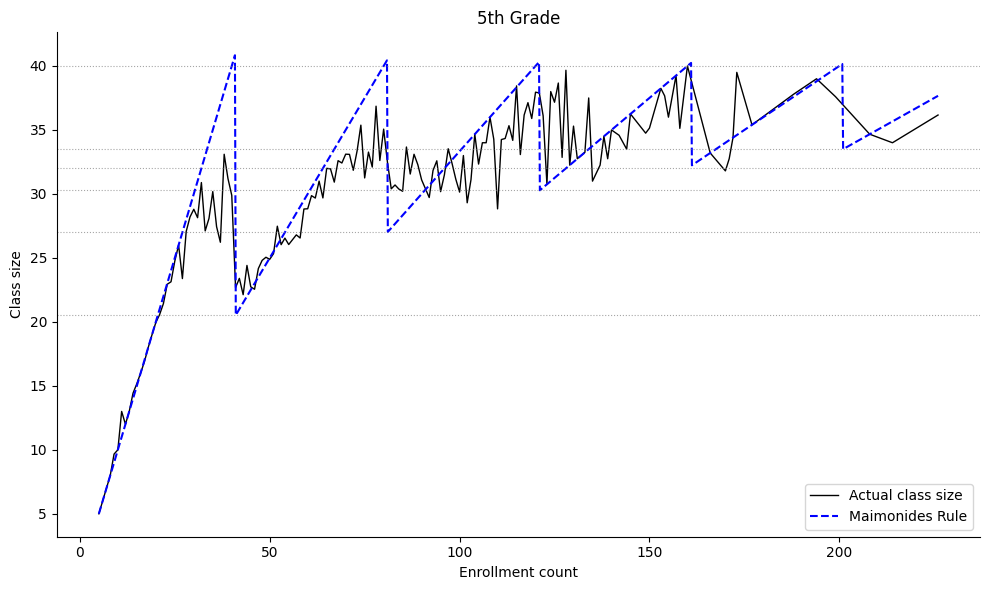

In [302]:
plot_maimonides_sawtooth(df_grade5)

In [ ]:
def plot_scores_vs_predicted(df):

    grade = df["grade"][0]

    # 1. Prepare the binned data (Intervals of 10 as per paper)
    df['enroll_bin'] = (pd.cut(df['c_size'], bins=range(0, 170, 10), labels=range(5, 165, 10))
                        .astype(float))
    
    # Calculate the Maimonides Instrument for the bins
    bin_centers = np.sort(df['enroll_bin'].unique())
    f_sc = bin_centers / (np.floor((bin_centers - 1) / 40) + 1)
    
    # Calculate average test scores per bin
    bin_means = df.groupby('enroll_bin')['avgverb'].mean()

    # 2. Setup the Plot with Two Y-Axes
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # --- Left Axis: Test Scores ---
    line1, = ax1.plot(bin_means.index, bin_means.values, color='black', label='Average test scores')
    ax1.set_xlabel('Enrollment count')
    ax1.set_ylabel('Average reading score')
    ax1.set_ylim(68, 80)
    ax1.set_xticks(range(5, 170, 20))

    # --- Right Axis: Predicted Class Size ---
    ax2 = ax1.twinx()
    line2, = ax2.plot(bin_centers, f_sc, color='blue', linestyle='--', label='Predicted class size')
    ax2.set_ylabel('Average size function')
    ax2.set_ylim(5, 40)

    # 3. Add horizontal reference lines (The 'Corners')
    for y in [20.5, 27, 30.3, 33.5, 40]:
        ax2.axhline(y=y, color='gray', linestyle=':', linewidth=0.8)

    # Combine handles from both axes so both labels appear in one legend.
    ax1.legend(handles=[line1, line2], frameon=True, loc='lower right')

    plt.title(f'{grade}th Grade')
    plt.tight_layout()
    plt.show()

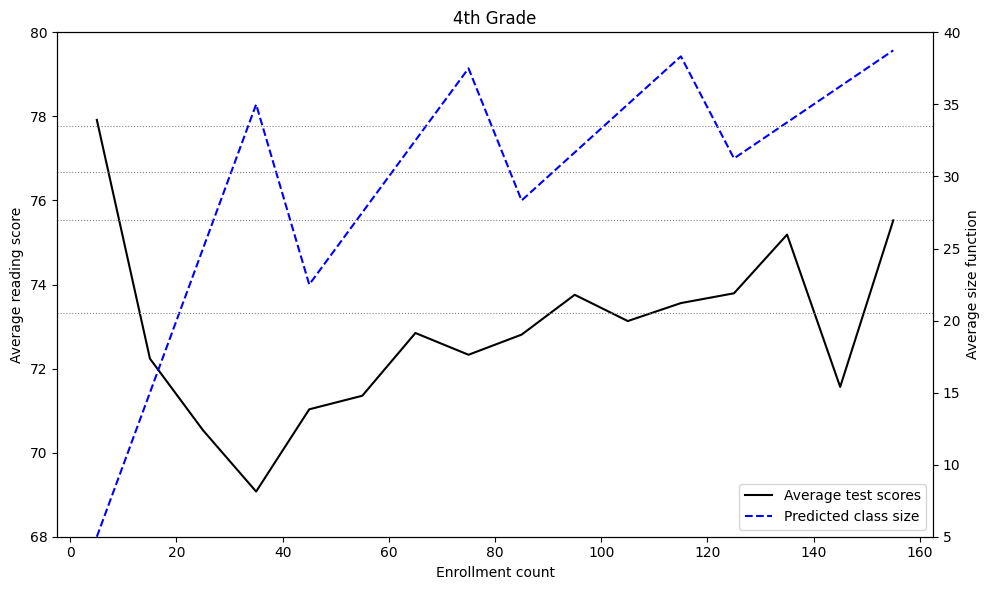

In [310]:
plot_scores_vs_predicted(df_grade4)

In [297]:
def plot_residual(df):

    grade = df["grade"][0]

    # 1. Calculate the Maimonides Rule (The Instrument)
    df['f_sc'] = df['c_size'] / (np.floor((df['c_size'] - 1) / 40) + 1)

    # 2. Define the Controls (X_s)
    valid = df[['avgverb', 'tipuach', 'c_size']].dropna().index
    X = sm.add_constant(df.loc[valid, ['tipuach', 'c_size']])

    # 3. Calculate Residuals
    model_y = sm.OLS(df.loc[valid, 'avgverb'], X).fit()
    df['y_resid'] = np.nan
    df.loc[valid, 'y_resid'] = model_y.resid

    model_f = sm.OLS(df.loc[valid, 'f_sc'], X).fit()
    df['f_resid'] = np.nan
    df.loc[valid, 'f_resid'] = model_f.resid

    # 4. Bin by 10s and calculate midpoints (5, 15, 25...)
    df['bin'] = (pd.cut(df['c_size'], bins=range(0, 170, 10), labels=range(5, 165, 10))
                 .astype(float))

    bin_means = df.groupby('bin').agg({'y_resid': 'mean', 'f_resid': 'mean'})

    # 5. Plotting with Dual Axes
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Left Axis: Score Residuals (Solid line)
    line1, = ax1.plot(bin_means.index, bin_means['y_resid'], color='black', label='Average test scores')
    ax1.set_ylabel('Reading score residual')
    ax1.set_xlabel('Enrollment count')
    ax1.set_ylim(-5, 5)

    # Right Axis: Size Residuals (Dashed line)
    ax2 = ax1.twinx()
    line2, = ax2.plot(bin_means.index, bin_means['f_resid'], color='blue', linestyle='--', label='Predicted class size')
    ax2.set_ylabel('Size-function residual')
    ax2.set_ylim(-15, 15)

    # Combine line handles from both axes so both labels appear in one legend.
    ax1.legend(handles=[line1, line2], loc='lower right', frameon=True)

    plt.title(f'{grade}th Grade')
    plt.tight_layout()
    plt.show()

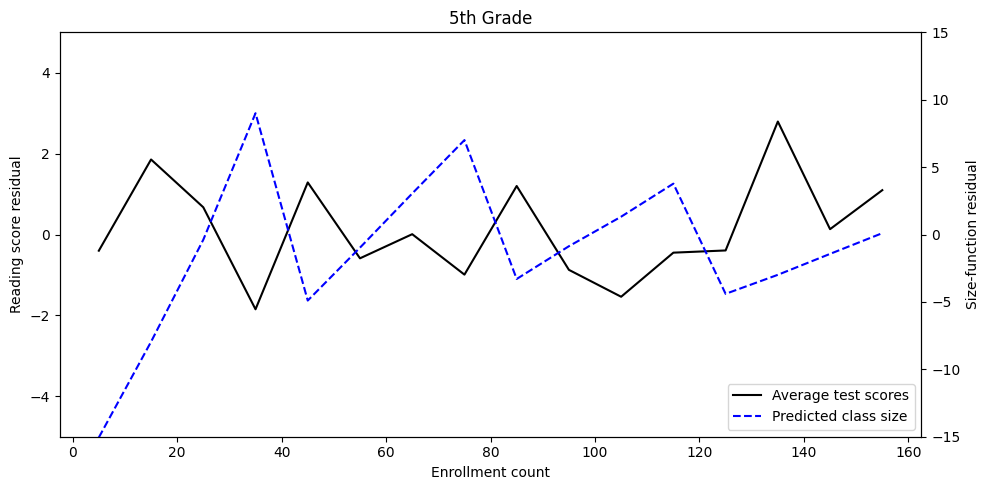

In [311]:
plot_residual(df_grade5)